<a href="https://colab.research.google.com/github/DannyJung23/SatelliteDataAI-UoA/blob/main/My-Lab-Notebooks/761_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up

In [18]:
# Install geemap package
!pip install geemap --quiet

In [19]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='uoa-gisci')

In [20]:
# Import required libraries
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
import urllib.request
import tempfile
import zipfile
import glob
import os

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from google.colab import files

# Define Area of Interest (AOI)

In [21]:
# Wellington, NZ
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [22]:
# S2 Cloud Masking Function
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Filter the S2 SR collection
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median()
      .clip(aoi))

(1) What other mathematical compositing approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

In [23]:
# Set up the visualisation
Map = geemap.Map(center=[-41.3, 174.75], zoom=11)
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Training Data

Land cover map used: ESA WorldCover 10m v100

In [24]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Change the valid classes to a sequential list
remap_to = ee.List.sequence(1, 10)

# Load land cover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

In [25]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped)

In [26]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())


First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3140000104904175
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)

# Random Forest Classification for Landcover

In [27]:
# Add random column
sample = sample.randomColumn('random')

# Apply 70/20/10 split to the samples
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Set up a classifier object using the pre-built [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest#colab-python) model.

In [28]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

In [29]:
# Apply the classifier
classified = s2.select(bands).classify(classifier)

In [30]:
# Visualise the classified image
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified.randomVisualizer(), {}, 'Classified')
Map.addLayer(landcover_remapped.randomVisualizer(), {} ,'ESA Landcover')
Map

Map(center=[-41.300046246343555, 174.75000000000097], controls=(WidgetControl(options=['position', 'transparen…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

Apply the validation data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall).

In [31]:
# Apply classifier to validation samples and add 'predicted' label
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Print summary statistics
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                   columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       19        0        6        0        0   
Actual 20         0        0        2        0        0        0        0   
Actual 30        36        0      118        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        7        0       27        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:

- Landcover maps of Wellington for 2018, 2022 and 2024
- The Test accuracy averages of the RF classifier for 2020.
- Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)

## Code for Q5

**Approach:**
- Create consistent annual S2 SR composites for 2018, 2020, 2022, and 2024 using the same filters. Use SCL-based cloud masking instead of using QA60 band since QA60 was empty or missing in S2 SR products for data acquired between 2022 and 2024.
- Use the 2020 S2 composite together with ESA WorldCover 2020 as the reference dataset for training the Random Forest classifier.
- Evaluate the trained RF model on the 2020 test set using a confusion matrix, overall accuracy, and macro- and weighted-average precision, recall, and F1-score.
- Apply the same 2020-trained classifier to the 2018, 2022, and 2024 composites.
- Apply a consistent land cover colour scheme to all images.
- Produce a figure containing the 3 classified land cover maps, a shared legend, map elements, and the 2020 test accuracy averages statistics.

Prepare reusable functions for SCl cloud masking and annual composite.

In [32]:
# Function for S2 Cloud Masking using Scene Classification Layer (SCL)
def mask_s2_clouds_q5(image_q5):
    scl_q5 = image_q5.select('SCL')
    mask_q5 = (
        scl_q5.neq(3)
        .And(scl_q5.neq(8))
        .And(scl_q5.neq(9))
        .And(scl_q5.neq(10))
    )
    return(
        image_q5
        .updateMask(mask_q5)
        .divide(10000)
        .select(bands_q5)
        .copyProperties(image_q5, ['system:time_start'])
    )

In [33]:
# Function for creating an annual cloud-masked S2 median composite
def make_s2_composite_q5(year_q5):
    start_date_q5 = ee.Date.fromYMD(year_q5, 1, 1)
    end_date_q5 = start_date_q5.advance(1, 'year')

    composite_q5 = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date_q5, end_date_q5)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
        .map(mask_s2_clouds_q5)
        .median()
        .clip(aoi)
    )

    return composite_q5

In [34]:
bands_q5 = ['B2', 'B3', 'B4', 'B8']

# Create annual Sentinel-2 composites
s2_2018_q5 = make_s2_composite_q5(2018)
s2_2020_q5 = make_s2_composite_q5(2020)
s2_2022_q5 = make_s2_composite_q5(2022)
s2_2024_q5 = make_s2_composite_q5(2024)

Load the ESA WorldCover 2020 map for the AOI and remap its original class values to consecutive class IDs for use by the classifier.

In [35]:
# Define valid WorldCover classes
valid_classes_q5 = ee.List.sequence(10, 100, 10)

# Remap original WorldCover classes to consecutive integers
remap_to_q5 = ee.List.sequence(1, 10)

# Load ESA WorldCover 2020
landcover_q5 = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: (10 → 1, ..., 100 → 10)
landcover_remapped_q5 = landcover_q5.remap(valid_classes_q5, remap_to_q5).rename('Map_remapped')

Construct the training dataset. (2020 S2 spectral bands + remapped 2020 WorldCover labels)

In [36]:
# Add landcover original and remapped as bands to S2 2020 image
training_data_q5 = s2_2020_q5.addBands(landcover_remapped_q5)

In [37]:
# Sample the image and corresponding land-cover labels
sample_q5 = training_data_q5.select(bands_q5 + ['Map_remapped']).sample(
        region=aoi,
        scale=10,
        numPixels=5000,
        seed=2,
        geometries=True)

Train-validation-test data split.

In [38]:
# Add random column
sample_q5 = sample_q5.randomColumn('random_q5')

# Split 70:20:10
train_q5 = sample_q5.filter(ee.Filter.lt('random_q5', 0.7))
valid_q5 = sample_q5.filter(ee.Filter.And(ee.Filter.gte('random_q5', 0.7), ee.Filter.lt('random_q5', 0.9)))
test_q5 = sample_q5.filter(ee.Filter.gte('random_q5', 0.9))

Train Random Forest model.

In [39]:
# Train Random Forest model using only the 2020 training data
classifier_q5 = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
        features=train_q5,
        classProperty='Map_remapped',
        inputProperties=bands_q5)

In [40]:
# Apply the trained classifier to the 2020 test data
tested_q5 = test_q5.classify(classifier_q5, 'predicted_q5')

In [41]:
# Function to export data for confusion matrix
def fc_to_lists_q5(fc_q5, classProp_q5, predProp_q5):
    values_q5 = fc_q5.aggregate_array(classProp_q5).getInfo()
    pred_q5 = fc_q5.aggregate_array(predProp_q5).getInfo()
    return values_q5, pred_q5

# Get predicted vs actual from test set
y_true_q5, y_pred_q5 = fc_to_lists_q5(tested_q5, 'Map_remapped', 'predicted_q5')

Accuracy assessment by comparing the predicted and reference test labels using a confusion matrix and classification report, and calculate the calssification accuracy.

In [42]:
# Labels for original classes
label_map_q5 = {index_q5 + 1: valid_classes_q5.get(index_q5).getInfo() for index_q5 in range(10)}
label_names_q5 = [label_map_q5[index_q5 + 1] for index_q5 in range(10)]

# Confusion matrix for 2020 test
cm_q5 = confusion_matrix(y_true_q5, y_pred_q5, labels=list(range(1, 11)))

# Classification report as a dictionary for later use in the figure
report_dict_q5 = classification_report(
    y_true_q5,
    y_pred_q5,
    labels=list(range(1, 11)),
    target_names=[str(label_q5) for label_q5 in label_names_q5],
    zero_division=0,
    output_dict=True
)

# Normal text report for inspection
report_text_q5 = classification_report(
    y_true_q5,
    y_pred_q5,
    labels=list(range(1, 11)),
    target_names=[str(label_q5) for label_q5 in label_names_q5],
    zero_division=0
)

# Overall test accuracy
accuracy_q5 = accuracy_score(y_true_q5, y_pred_q5)


print('Confusion Matrix:')
print(pd.DataFrame(cm_q5, index=[f'Actual {label_q5}' for label_q5 in label_names_q5],
                          columns=[f'Pred {label_q5}' for label_q5 in label_names_q5]))

print('\nClassification Report:')
print(report_text_q5)

print(f'\nOverall 2020 Test Accuracy: ' f'{accuracy_q5:.3f}')

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10        92        0       15        0        2        0        0   
Actual 20         0        0        0        0        0        0        0   
Actual 30        15        0       61        0        3        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         3        0        3        0       19        1        0   
Actual 60         0        0        0        0        2        1        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        1        0        1        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

Extract the macro- and weighted-average precision, recall, and F1-scores from the classification report for inclusion in the final figure.

In [43]:
# Extract macro-average statistics
macro_precision_q5 = (report_dict_q5['macro avg']['precision'])
macro_recall_q5 = (report_dict_q5['macro avg']['recall'])
macro_f1_q5 = (report_dict_q5['macro avg']['f1-score'])

# Extract weighted-average statistics
weighted_precision_q5 = (report_dict_q5['weighted avg']['precision'])
weighted_recall_q5 = (report_dict_q5['weighted avg']['recall'])
weighted_f1_q5 = (report_dict_q5['weighted avg']['f1-score'])

Apply the same RF classifier trained on 2020 data to the 2018, 2022, and 2024 composites. The classifier is not retrained for the other years, allowing the temporal classifications to be produced using a consistent model.

In [44]:
# Apply the 2020-trained classifier to each year's image
classified_2018_q5 = s2_2018_q5.select(bands_q5).classify(classifier_q5)
classified_2022_q5 = s2_2022_q5.select(bands_q5).classify(classifier_q5)
classified_2024_q5 = s2_2024_q5.select(bands_q5).classify(classifier_q5)

Define a common colour palette for the land cover classes instead of using randomVisualizer() so that each class is represented by the same colour in every year.

In [45]:
# Consistent land cover palette
palette_q5 = [
    '006400',  # 1  Tree cover
    'ffbb22',  # 2  Shrubland
    'ffff4c',  # 3  Grassland
    'f096ff',  # 4  Cropland
    'fa0000',  # 5  Built-up
    'b4b4b4',  # 6  Bare / sparse vegetation
    'f0f0f0',  # 7  Snow and ice
    '0064c8',  # 8  Permanent water bodies
    '0096a0',  # 9  Herbaceous wetland
    'fae6a0'   # 10 Moss and lichen
]

visualisation_q5 = {
    'min': 1,
    'max': 10,
    'palette': palette_q5
}

Visual quality check.

In [46]:
# Display classified 2018, 2022, 2024 images
Map_q5 = geemap.Map()
Map_q5.centerObject(aoi, 10)
Map_q5.addLayer(classified_2018_q5, visualisation_q5, '2018 Classified Landcover')
Map_q5.addLayer(classified_2022_q5, visualisation_q5, '2022 Classified Landcover')
Map_q5.addLayer(classified_2024_q5, visualisation_q5, '2024 Classified Landcover')
Map_q5

Map(center=[-41.30004624634492, 174.74999999999935], controls=(WidgetControl(options=['position', 'transparent…

The following codes are for constructing the final figure.

In [47]:
# Extract plotting extent from the AOI
aoi_coordinates_q5 = (aoi.bounds().coordinates().getInfo()[0])
longitudes_q5 = [coordinate_q5[0] for coordinate_q5 in aoi_coordinates_q5]
latitudes_q5 = [coordinate_q5[1] for coordinate_q5 in aoi_coordinates_q5]
extent_q5 = [min(longitudes_q5), max(longitudes_q5), min(latitudes_q5), max(latitudes_q5)]
extent_q5

[174.6, 174.9, -41.40009740076528, -41.199999999999974]

In [48]:
# Function for downloading a rendered EE image
def download_classified_image(classified_image):
    image_url = classified_image.getThumbURL({
        'region': aoi,
        'dimensions': 1400,
        'min': 1,
        'max': 10,
        'palette': palette_q5,
        'format': 'png'
    })
    temporary_file = tempfile.NamedTemporaryFile(
        suffix='.png',
        delete=False
    )
    temporary_file.close()
    urllib.request.urlretrieve(
        image_url,
        temporary_file.name
    )
    downloaded_image = mpimg.imread(
        temporary_file.name
    )
    return downloaded_image

In [49]:
# Download each classified image for the final figure
image_2018_q5 = download_classified_image(classified_2018_q5)
image_2022_q5 = download_classified_image(classified_2022_q5)
image_2024_q5 = download_classified_image(classified_2024_q5)

In [50]:
# Land cover class names for the shared figure legend
class_names_q5 = [
    'Tree cover',
    'Shrubland',
    'Grassland',
    'Cropland',
    'Built-up',
    'Bare / sparse vegetation',
    'Snow and ice',
    'Permanent water bodies',
    'Herbaceous wetland',
    'Moss and lichen'
]

legend_handles_q5 = [
    mpatches.Patch(
        facecolor=f'#{palette_q5[index_q5]}',
        label=class_names_q5[index_q5]
    )
    for index_q5 in range(10)
]

In [51]:
# Add a north arrow and scale bar to a map panel
def add_map_elements_q5(axis):

    # North arrow
    axis.annotate(
        'N',
        xy=(0.92, 0.92),
        xytext=(0.92, 0.78),
        xycoords='axes fraction',
        textcoords='axes fraction',
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='-|>',
            linewidth=1.5,
            color='black'
        )
    )

    # 5 km scale bar
    mean_latitude_q5 = (extent_q5[2] + extent_q5[3]) / 2
    degrees_per_5km_q5 = (5 / (111.32 * np.cos(np.deg2rad(mean_latitude_q5))))
    x_start_q5 = (extent_q5[0] + 0.07 * (extent_q5[1] - extent_q5[0]))
    y_start_q5 = (extent_q5[2] + 0.07 * (extent_q5[3] - extent_q5[2]))
    x_end_q5 = (x_start_q5 + degrees_per_5km_q5)
    axis.plot([x_start_q5, x_end_q5], [y_start_q5, y_start_q5], color='black', linewidth=3)
    axis.plot([x_start_q5, x_start_q5], [y_start_q5 - 0.002, y_start_q5 + 0.002], color='black', linewidth=1.5)
    axis.plot([x_end_q5, x_end_q5], [y_start_q5 - 0.002, y_start_q5 + 0.002], color='black', linewidth=1.5)
    axis.text((x_start_q5 + x_end_q5) / 2, y_start_q5 + 0.005, '5 km', ha='center', va='bottom', fontsize=9)

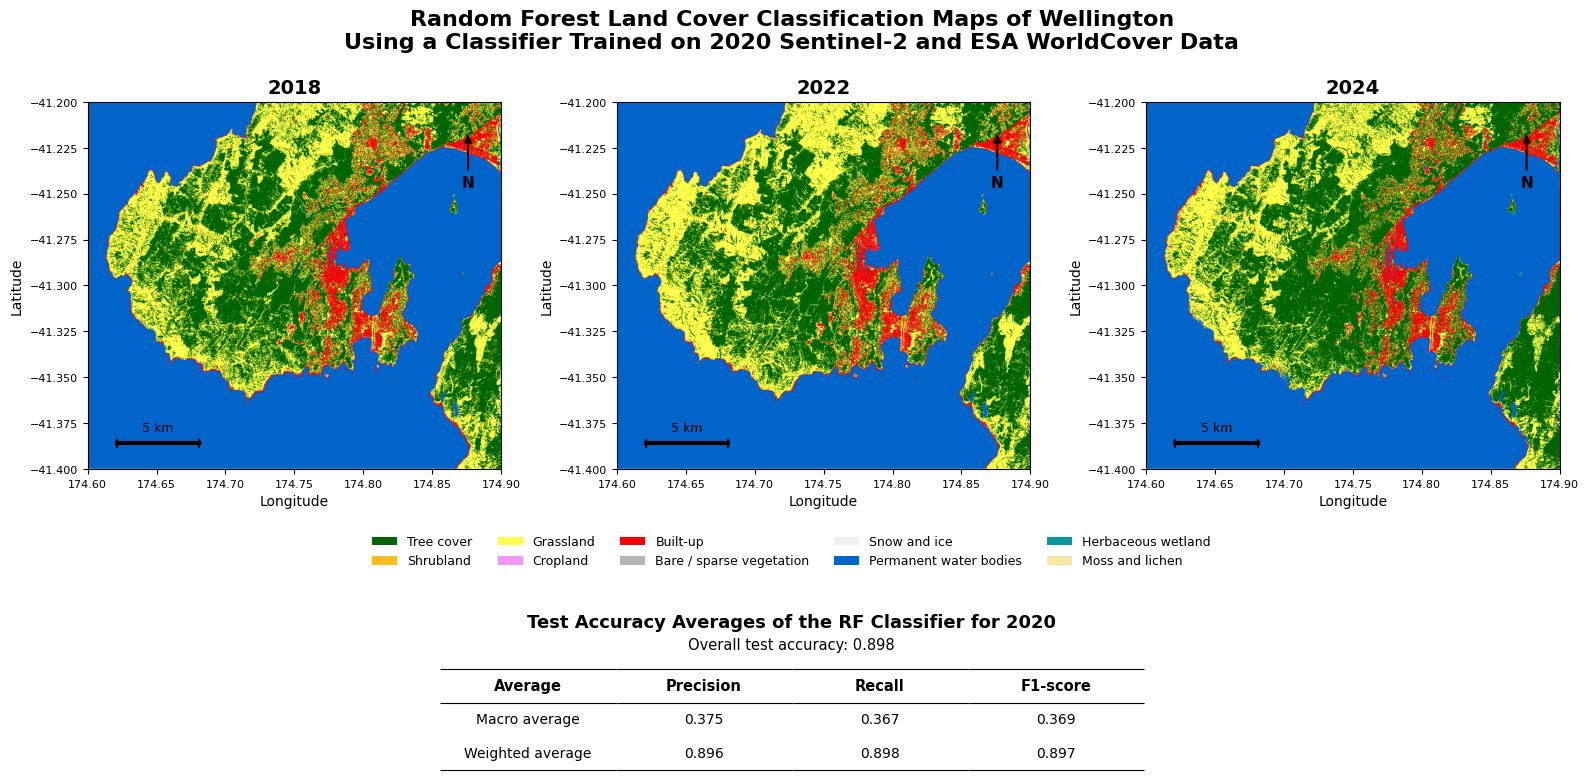

Figure 1. Random Forest land cover classifications of Wellington for 2018, 2022, and 2024, produced by applying a classifier trained using 2020 Sentinel-2 spectral bands (B2, B3, B4, and B8) and ESA WorldCover 2020 reference labels. Classification accuracy is only for 2020 because the matched reference land cover data used for RF model training are from 2020. The accuracy of the 2018, 2022, and 2024 classifications cannot be determined without independent reference data corresponding to those years.


In [52]:
map_images_q5 = [image_2018_q5, image_2022_q5, image_2024_q5]
map_years_q5 = [2018, 2022, 2024]

# Create figure
figure_q5, axes_q5 = plt.subplots(nrows=1, ncols=3, figsize=(16, 8.5))

for axis_q5, map_image_q5, map_year_q5 in zip(
    axes_q5,
    map_images_q5,
    map_years_q5
):
    axis_q5.imshow(map_image_q5, extent=extent_q5, origin='upper')
    mean_latitude_q5 = (extent_q5[2] + extent_q5[3]) / 2
    axis_q5.set_aspect(1 / np.cos(np.deg2rad(mean_latitude_q5)))
    axis_q5.set_title(f'{map_year_q5}', fontsize=14, fontweight='bold')
    axis_q5.set_xlabel('Longitude', fontsize=10)
    axis_q5.set_ylabel('Latitude', fontsize=10)
    axis_q5.tick_params(labelsize=8)
    add_map_elements_q5(axis_q5)

# Main title
figure_q5.suptitle(
    'Random Forest Land Cover Classification Maps of Wellington\n'
    'Using a Classifier Trained on 2020 Sentinel-2 and ESA WorldCover Data',
    fontsize=16,
    fontweight='bold',
    y=0.94
)

# Shared land cover legend
figure_q5.legend(
    handles=legend_handles_q5,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.27),
    ncol=5,
    frameon=False,
    fontsize=9
)

# Performance table
performance_table_data_q5 = [
    [
        'Macro average',
        f'{macro_precision_q5:.3f}',
        f'{macro_recall_q5:.3f}',
        f'{macro_f1_q5:.3f}'
    ],
    [
        'Weighted average',
        f'{weighted_precision_q5:.3f}',
        f'{weighted_recall_q5:.3f}',
        f'{weighted_f1_q5:.3f}'
    ]
]

performance_column_labels_q5 = [
    'Average',
    'Precision',
    'Recall',
    'F1-score'
]

table_axis_q5 = figure_q5.add_axes([
    0.28,
    0.045,
    0.44,
    0.145
])

table_axis_q5.axis('off')

table_axis_q5.text(
    0.5,
    1.20,
    'Test Accuracy Averages of the RF Classifier for 2020',
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold',
    transform=table_axis_q5.transAxes
)

table_axis_q5.text(
    0.5,
    1.02,
    f'Overall test accuracy: {accuracy_q5:.3f}',
    ha='center',
    va='center',
    fontsize=10.5,
    transform=table_axis_q5.transAxes
)

performance_table_q5 = table_axis_q5.table(
    cellText=performance_table_data_q5,
    colLabels=performance_column_labels_q5,
    cellLoc='center',
    colLoc='center',
    loc='center',
    bbox=[0, 0, 1, 0.82]
)

performance_table_q5.auto_set_font_size(False)
performance_table_q5.set_fontsize(10)

cells_q5 = performance_table_q5.get_celld()

for (row_q5, col_q5), cell_q5 in cells_q5.items():
    cell_q5.set_facecolor('white')
    cell_q5.set_edgecolor('black')
    cell_q5.set_linewidth(0)
    cell_q5.visible_edges = ''

    if row_q5 == 0:
        cell_q5.set_text_props(
            fontweight='bold',
            fontsize=10.5
        )

for col_q5 in range(4):
    cells_q5[(0, col_q5)].visible_edges = 'TB'
    cells_q5[(0, col_q5)].set_linewidth(0.8)

for col_q5 in range(4):
    cells_q5[(2, col_q5)].visible_edges = 'B'
    cells_q5[(2, col_q5)].set_linewidth(0.8)

performance_table_q5.scale(1.0, 1.35)

plt.subplots_adjust(
    top=0.84,
    bottom=0.39,
    left=0.06,
    right=0.98,
    wspace=0.28
)

# Generate a figure caption
caption_q5 = (
    'Figure 1. Random Forest land cover classifications of Wellington '
    'for 2018, 2022, and 2024, produced by applying a classifier trained '
    'using 2020 Sentinel-2 spectral bands (B2, B3, B4, and B8) and '
    'ESA WorldCover 2020 reference labels. '
    'Classification accuracy is only for 2020 because the matched reference '
    'land cover data used for RF model training are from 2020. '
    'The accuracy of the 2018, 2022, and 2024 classifications cannot be '
    'determined without independent reference data corresponding to those years.'
)

plt.show()
print(caption_q5)

(6) Exercise: using an SVM model and the Landcare NZ 2024 landcover database, produce a landcover map of Great Barrier (Aotea) Island for 2025 (based off the Austral summer of 24/25).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.
- Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithm. I have provided some starter code below.

An initial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas. (25 pts)


## Code for Q6

Before constructing the SVM classifier, the exported LCDB v6.0 dataset was inspected to determine how it should be used as training data. The data export contains 558 valid polygon features in NZTM2000 (EPSG:2193), with the most recent land-cover information stored in Class_2023 and Name_2023. A total of 22 land-cover classes are present within the study area.

For modelling, the 2023 LCDB classes will provide the reference labels for Sentinel-2 imagery from the 2023/24 Austral summer. Consecutive numeric class IDs will be created for SVM training while preserving the original LCDB class codes and names for interpretation and figure legends. The trained model will then be applied to Sentinel-2 imagery from the 2024/25 Austral summer to produce the 2025 land-cover classification.

Before running the following cells, the exported LCDB v6.0 ZIP file was manually uploaded to the Colab runtime.

**Approach:**
- Import and inspect the LCDB vector dataset exported for Great Barrier Island, using the 2023 land cover classes as reference labels for model training.
- Convert the original LCDB class codes to consecutive SVM class IDs while preserving the original class names and codes for interpretation and figure labelling.
- Prepare S2 SR imagery for the 2023/24 and 2024/25 Austral summers, using SCL-based pixel-level cloud masking and median compositing.
- Construct an expanded predictor set using S2 visible, red-edge, NIR and SWIR bands together with NDVI, NDRE, NDMI, MNDWI and BSI to improve separation among the 22 detailed LCDB classes.
- Combine the 2023/24 S2 predictor composite with the LCDB 2023 reference labels to create the SVM dataset.
- Use an area-informed moderately balanced sampling strategy, rather than either purely random or equally balanced sampling, to retain information about the natural class distribution while ensuring representation of rare classes.
- Split the samples into 80% training, 10% validation and 10% testing subsets, and train an RBF SVM classifier.
- Assess the classifier using the test data, reporting overall accuracy and macro- and weighted-average precision, recall and F1-score.
- Apply the trained SVM to the 2024/25 Austral summer S2 composite to produce the 2025 land cover classification, restricting predictions to the LCDB-mapped footprint.


**LCDB v6.0 Dataset used:**
- https://lris.scinfo.org.nz/layer/123148-lcdb-v60-land-cover-database-version-60-mainland-new-zealand/

Analyse dataset before constructing the classifier.

In [53]:
# Unzip and load the exported LCDB shapefile
zip_path_q6 = '/content/lris-lcdb-v60-land-cover-database-version-60-mainland-new-zealand-SHP.zip'
extract_folder_q6 = '/content/lcdb_q6'

# Extract the ZIP file
with zipfile.ZipFile(zip_path_q6, 'r') as zip_ref_q6:
    zip_ref_q6.extractall(extract_folder_q6)

# Find the shapefile
shp_path_q6 = glob.glob(os.path.join(extract_folder_q6, '*.shp'))[0]

# Load into a GeoDataFrame
gdf_q6 = gpd.read_file(shp_path_q6)

# Basic dataset checks
print(f'Features: {len(gdf_q6)}')
print(f'CRS: {gdf_q6.crs}')
print('Geometry types:')
print(gdf_q6.geometry.geom_type.value_counts())
print(f'Invalid geometries: {(~gdf_q6.geometry.is_valid).sum()}')

Features: 558
CRS: EPSG:2193
Geometry types:
Polygon    558
Name: count, dtype: int64
Invalid geometries: 0


In [54]:
# Inspect the latest LCDB land-cover classes present in the AOI
class_summary_q6 = (
    gdf_q6[['Class_2023', 'Name_2023']]
    .drop_duplicates()
    .sort_values('Class_2023')
    .reset_index(drop=True)
)

class_summary_q6

,Class_2023,Name_2023
0,1,Built-up Area (settlement)
1,2,Urban Parkland/Open Space
2,5,Transport Infrastructure
3,6,Surface Mine or Dump
4,10,Sand and Gravel
5,12,Landslide
6,16,Gravel and Rock
7,20,Lake or Pond
8,21,River
9,22,Estuarine Open Water


In [55]:
# Examine class distribution by mapped area
gdf_q6['Area_km2_q6'] = gdf_q6.geometry.area / 1_000_000

class_area_q6 = (
    gdf_q6
    .groupby(['Class_2023', 'Name_2023'])['Area_km2_q6']
    .sum()
    .reset_index()
    .sort_values('Area_km2_q6', ascending=False)
)

class_area_q6

,Class_2023,Name_2023,Area_km2_q6
16,52,Manuka and/or Kanuka,148.510967
19,69,Indigenous Forest,62.930645
17,54,Broadleaved Indigenous Hardwoods,42.802654
11,40,High Producing Exotic Grassland,16.118073
4,10,Sand and Gravel,7.181777
12,41,Low Producing Grassland,3.446331
13,45,Herbaceous Freshwater Vegetation,2.870141
14,46,Herbaceous Saline Vegetation,1.551585
20,70,Mangrove,1.353301
21,71,Exotic Forest,1.274327


In [56]:
# Check the onshore/offshore status of the exported LCDB polygons
print(gdf_q6['Onshore_23'].value_counts())

Onshore_23
yes    546
no      12
Name: count, dtype: int64


The 22 LCDB classes are highly uneven in their mapped extent. This imbalance is considered when constructing the training sample so that common classes remain appropriately represented without excluding rare classes.

In [57]:
# Create sequential class IDs for SVM training
class_mapping_q6 = (
    gdf_q6[['Class_2023', 'Name_2023']]
    .drop_duplicates()
    .sort_values('Class_2023')
    .reset_index(drop=True)
)

class_mapping_q6['SVM_Class_q6'] = range(
    1,
    len(class_mapping_q6) + 1
)

class_mapping_q6

,Class_2023,Name_2023,SVM_Class_q6
0,1,Built-up Area (settlement),1
1,2,Urban Parkland/Open Space,2
2,5,Transport Infrastructure,3
3,6,Surface Mine or Dump,4
4,10,Sand and Gravel,5
5,12,Landslide,6
6,16,Gravel and Rock,7
7,20,Lake or Pond,8
8,21,River,9
9,22,Estuarine Open Water,10


In [58]:
# Add the sequential SVM class IDs to the LCDB polygons
gdf_q6 = gdf_q6.merge(
    class_mapping_q6[['Class_2023', 'SVM_Class_q6']],
    on='Class_2023',
    how='left'
)

print('Missing SVM labels:', gdf_q6['SVM_Class_q6'].isna().sum())

gdf_q6[['Class_2023', 'Name_2023', 'SVM_Class_q6']].head()

Missing SVM labels: 0


,Class_2023,Name_2023,SVM_Class_q6
0,10,Sand and Gravel,5
1,52,Manuka and/or Kanuka,17
2,69,Indigenous Forest,20
3,10,Sand and Gravel,5
4,10,Sand and Gravel,5


The LCDB polygons are reprojected from NZTM2000 to WGS84 and transferred to EE so that they can be spatially combined with the S2 imagery.

In [59]:
# Reproject the LCDB polygons to WGS84 for Earth Engine
gdf_ee_q6 = gdf_q6.to_crs(epsg=4326)

print('CRS:', gdf_ee_q6.crs)
print('Bounds:', gdf_ee_q6.total_bounds)

CRS: EPSG:4326
Bounds: [175.28179689 -36.34920981 175.55101253 -36.02511126]


In [60]:
# Convert the LCDB GeoDataFrame to an Earth Engine FeatureCollection
lcdb_fc_q6 = geemap.gdf_to_ee(gdf_ee_q6)

print('LCDB polygons in Earth Engine:',lcdb_fc_q6.size().getInfo())

LCDB polygons in Earth Engine: 558


In [61]:
# Define the AOI from the LCDB export extent directly
aoi_q6 = lcdb_fc_q6.geometry().bounds()

The LCDB polygon classes are converted to a raster label band so that each S2 pixel within the mapped LCDB footprint can be associated directly with its corresponding reference land cover class.

In [62]:
# Rasterise the sequential LCDB class labels
lcdb_label_q6 = (lcdb_fc_q6.reduceToImage(properties=['SVM_Class_q6'], reducer=ee.Reducer.first())
    .rename('SVM_Class_q6')
    .toInt())

Predictor selection. Because the LCDB contains several spectrally similar vegetation and surface classes, the predictor set is expanded beyond the visible and NIR bands used previously. S2 red-edge and SWIR bands are included together with spectral indicies representing vegetation condition, moisture, water and exposed surfaces to improve class separability.

In [63]:
spectral_bands_q6 = [
    'B2', 'B3', 'B4',          # Blue, Green, Red
    'B5', 'B6', 'B7',          # Red-edge bands
    'B8', 'B8A',               # NIR
    'B11', 'B12'               # SWIR
]

# Final predictor variables used by the SVM
bands_q6 = spectral_bands_q6 + [
    'NDVI',
    'NDRE',
    'NDMI',
    'MNDWI',
    'BSI'
]

In [64]:
# Function for S2 Cloud Masking using Scene Classification Layer (SCL) and construct SVM predictor variables
def prepare_s2_q6(image_q6):
    scl_q6 = image_q6.select('SCL')
    mask_q6 = (
        scl_q6.neq(0)          # No data
        .And(scl_q6.neq(1))    # Saturated / defective
        .And(scl_q6.neq(3))    # Cloud shadow
        .And(scl_q6.neq(8))    # Medium-probability cloud
        .And(scl_q6.neq(9))    # High-probability cloud
        .And(scl_q6.neq(10))   # Thin cirrus
        .And(scl_q6.neq(11))   # Snow / ice
    )

    # Scale Sentinel-2 surface reflectance
    reflectance_q6 = (
        image_q6
        .select(spectral_bands_q6)
        .divide(10000)
        .updateMask(mask_q6)
    )

    # NDVI: vegetation greenness
    ndvi_q6 = reflectance_q6.expression(
        '(NIR - RED) / (NIR + RED + 1e-6)',
        {
            'NIR': reflectance_q6.select('B8'),
            'RED': reflectance_q6.select('B4')
        }
    ).rename('NDVI')

    # NDRE: red-edge vegetation response
    ndre_q6 = reflectance_q6.expression(
        '(NIR - RE) / (NIR + RE + 1e-6)',
        {
            'NIR': reflectance_q6.select('B8A'),
            'RE': reflectance_q6.select('B5')
        }
    ).rename('NDRE')

    # NDMI: vegetation / surface moisture
    ndmi_q6 = reflectance_q6.expression(
        '(NIR - SWIR) / (NIR + SWIR + 1e-6)',
        {
            'NIR': reflectance_q6.select('B8'),
            'SWIR': reflectance_q6.select('B11')
        }
    ).rename('NDMI')

    # MNDWI: water and wet surfaces
    mndwi_q6 = reflectance_q6.expression(
        '(GREEN - SWIR) / (GREEN + SWIR + 1e-6)',
        {
            'GREEN': reflectance_q6.select('B3'),
            'SWIR': reflectance_q6.select('B11')
        }
    ).rename('MNDWI')

    # BSI: exposed soil / rock / bare surfaces
    bsi_q6 = reflectance_q6.expression(
        '((SWIR + RED) - (NIR + BLUE)) / '
        '((SWIR + RED) + (NIR + BLUE) + 1e-6)',
        {
            'SWIR': reflectance_q6.select('B11'),
            'RED': reflectance_q6.select('B4'),
            'NIR': reflectance_q6.select('B8'),
            'BLUE': reflectance_q6.select('B2')
        }
    ).rename('BSI')

    return (
        reflectance_q6
        .addBands([
            ndvi_q6,
            ndre_q6,
            ndmi_q6,
            mndwi_q6,
            bsi_q6
        ])
        .copyProperties(
            image_q6,
            ['system:time_start']
        )
    )

Cloud masking and image preparation. Cloud contamination is handled at the pixel level using the Sentinel-2 Scene Classification Layer (SCL), rather than excluding entire scenes according to CLOUDY_PIXEL_PERCENTAGE. This retains useful cloud-free observations from partially cloudy scenes, which was important for obtaining adequate spatial coverage over AOI during the relatively short Austral-summer periods.

A small number of locations with no valid observations remaining after masking are retained as no-data rather than being artificially interpolated.

In [65]:
# Function for creating an Austral summer S2 median composite
def make_summer_composite_q6(start_year_q6):

    start_date_q6 = ee.Date.fromYMD(start_year_q6, 12, 1)
    end_date_q6 = ee.Date.fromYMD(start_year_q6 + 1, 3, 1)

    composite_q6 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi_q6)
        .filterDate(start_date_q6, end_date_q6)
        .map(prepare_s2_q6)
        .median()
        .clip(aoi_q6)
    )
    return composite_q6

In [66]:
# S2 composite temporally matched to LCDB
s2_2024_q6 = make_summer_composite_q6(2023)

# S2 composite used to create the 2025 land cover map
s2_2025_q6 = make_summer_composite_q6(2024)

The two summer composites are visually inspected before modelling to confirm adequate spatial coverage and check for remaining cloud or masking artefacts.

In [67]:
# Inspect the two summer composites before applying SVM
Map_q6 = geemap.Map()
Map_q6.centerObject(aoi_q6, 11)

rgb_vis_q6 = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}

Map_q6.addLayer(s2_2024_q6, rgb_vis_q6, 'Sentinel-2 Summer 2023/24')
Map_q6.addLayer(s2_2025_q6, rgb_vis_q6, 'Sentinel-2 Summer 2024/25')

Map_q6

Map(center=[-36.187073889065566, 175.41640470768527], controls=(WidgetControl(options=['position', 'transparen…

In [68]:
# Combine S2 predictors with the LCDB reference labels
training_image_q6 = (s2_2024_q6.select(bands_q6).addBands(lcdb_label_q6))

Sampling strategy: Initial inspection showed that purely random sampling strongly favoured the dominant vegetation classes and failed to represent several rare LCDB classes. Conversely, assigning the same number of samples to every class would substantially over-represent very small classes. A moderately balanced stratified approach is therefore used as a compromise.

Target sample sizes are scaled using the square root of each class's mapped area, with lower and upper limits applied to prevent extremely small or dominant sample groups. This preserves some information about the true class abundance while maintaining sufficient representation of uncommon classes for SVM training.

In [69]:
# Build an area-informed sampling plan
sampling_plan_q6 = (
    class_mapping_q6.merge(
        class_area_q6[['Class_2023', 'Area_km2_q6']],
        on='Class_2023',
        how='left'
    )
    .sort_values('SVM_Class_q6')
    .reset_index(drop=True)
)

In [70]:
# Moderately balance the classes while preserving some
# information about their true mapped abundance
sampling_plan_q6['Target_Samples_q6'] = (80 + 35 * np.sqrt(sampling_plan_q6['Area_km2_q6'])).round().clip(lower=80, upper=500).astype(int)
sampling_plan_q6[
    [
        'SVM_Class_q6',
        'Class_2023',
        'Name_2023',
        'Area_km2_q6',
        'Target_Samples_q6'
    ]
]

,SVM_Class_q6,Class_2023,Name_2023,Area_km2_q6,Target_Samples_q6
0,1,1,Built-up Area (settlement),0.687750,109
1,2,2,Urban Parkland/Open Space,0.219122,96
2,3,5,Transport Infrastructure,0.024758,86
3,4,6,Surface Mine or Dump,0.013076,84
4,5,10,Sand and Gravel,7.181777,174
5,6,12,Landslide,0.136753,93
6,7,16,Gravel and Rock,0.767633,111
7,8,20,Lake or Pond,0.014890,84
8,9,21,River,0.096463,91
9,10,22,Estuarine Open Water,0.823636,112


In [71]:
# Convert the sampling plan to lists for Earth Engine
class_values_q6 = (sampling_plan_q6['SVM_Class_q6'].astype(int).tolist())
class_points_q6 = (sampling_plan_q6['Target_Samples_q6'].astype(int).tolist())

print('Class values:')
print(class_values_q6)

print('\nTarget samples per class:')
print(class_points_q6)

Class values:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

Target samples per class:
[109, 96, 86, 84, 174, 93, 111, 84, 91, 112, 93, 221, 145, 139, 124, 107, 500, 309, 92, 358, 121, 120]


In [72]:
# Create a training dataset
sample_q6 = (
    training_image_q6
    .stratifiedSample(
        numPoints=100,
        classBand='SVM_Class_q6',
        classValues=class_values_q6,
        classPoints=class_points_q6,
        region=aoi_q6,
        scale=20,
        seed=2,
        dropNulls=True,
        tileScale=4,
        geometries=False
    )
)

print(
    'Total samples:',
    sample_q6.size().getInfo()
)

Total samples: 3276


In [73]:
# Inspect the number of sampled pixels for each class
sample_distribution_q6 = (sample_q6.aggregate_histogram('SVM_Class_q6').getInfo())

print('Samples per class:')
print(sample_distribution_q6)

Samples per class:
{'1': 109, '10': 112, '11': 93, '12': 221, '13': 145, '14': 139, '15': 124, '16': 107, '17': 500, '18': 309, '19': 92, '2': 96, '20': 358, '21': 121, '22': 120, '3': 86, '4': 22, '5': 174, '6': 93, '7': 111, '8': 53, '9': 91}


In [74]:
# Add a reproducible random column for train/validation/test splitting
sample_q6 = sample_q6.randomColumn(columnName='random_q6', seed=31)

# 80% training set
train_q6 = sample_q6.filter(ee.Filter.lt('random_q6', 0.8))

# 10% validation set
valid_q6 = sample_q6.filter(ee.Filter.And(ee.Filter.gte('random_q6', 0.8),ee.Filter.lt('random_q6', 0.9)))

# 10% final test set
test_q6 = sample_q6.filter(ee.Filter.gte('random_q6', 0.9))

print('Training samples:', train_q6.size().getInfo())
print('Validation samples:', valid_q6.size().getInfo())
print('Test samples:', test_q6.size().getInfo())

Training samples: 2608
Validation samples: 351
Test samples: 317


In [75]:
# Check class representation in each split
train_distribution_q6 = (train_q6.aggregate_histogram('SVM_Class_q6').getInfo())
valid_distribution_q6 = (valid_q6.aggregate_histogram('SVM_Class_q6').getInfo())
test_distribution_q6 = (test_q6.aggregate_histogram('SVM_Class_q6').getInfo())

print('Training class distribution:')
print(train_distribution_q6)

print('\nValidation class distribution:')
print(valid_distribution_q6)

print('\nTest class distribution:')
print(test_distribution_q6)

Training class distribution:
{'1': 82, '10': 82, '11': 73, '12': 180, '13': 111, '14': 106, '15': 105, '16': 86, '17': 391, '18': 240, '19': 70, '2': 76, '20': 301, '21': 92, '22': 92, '3': 71, '4': 19, '5': 144, '6': 76, '7': 91, '8': 39, '9': 81}

Validation class distribution:
{'1': 10, '10': 15, '11': 12, '12': 19, '13': 17, '14': 16, '15': 11, '16': 10, '17': 56, '18': 43, '19': 13, '2': 6, '20': 29, '21': 11, '22': 15, '3': 9, '4': 3, '5': 14, '6': 13, '7': 15, '8': 9, '9': 5}

Test class distribution:
{'1': 17, '10': 15, '11': 8, '12': 22, '13': 17, '14': 17, '15': 8, '16': 11, '17': 53, '18': 26, '19': 9, '2': 14, '20': 28, '21': 18, '22': 13, '3': 6, '5': 16, '6': 4, '7': 5, '8': 5, '9': 5}


An RBF-kernel SVM is trained using gamma = 0.5 and cost = 50, selected after comparing model performance across several candidate parameter combinations.

In [76]:
# Define and train the SVM classifier
svm_q6 = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=50).train(
        features=train_q6,
        classProperty='SVM_Class_q6',
        inputProperties=bands_q6
)

In [77]:
# Apply the trained SVM to validation and test samples
validated_q6 = valid_q6.classify(svm_q6, 'predicted_q6')
tested_q6 = test_q6.classify(svm_q6, 'predicted_q6')

In [78]:
# Convert reference and predicted labels to Python lists
def fc_to_lists_q6(feature_collection_q6, class_property_q6, prediction_property_q6):
    y_true_q6 = (feature_collection_q6.aggregate_array(class_property_q6).getInfo())
    y_pred_q6 = (feature_collection_q6.aggregate_array(prediction_property_q6).getInfo())
    return y_true_q6, y_pred_q6

In [79]:
y_true_q6, y_pred_q6 = fc_to_lists_q6(tested_q6, 'SVM_Class_q6', 'predicted_q6')

In [80]:
# Create mappings between SVM class IDs and LCDB class information
svm_to_name_q6 = dict(zip(class_mapping_q6['SVM_Class_q6'], class_mapping_q6['Name_2023']))
svm_to_lcdb_q6 = dict(zip(class_mapping_q6['SVM_Class_q6'], class_mapping_q6['Class_2023']))

class_ids_q6 = list(range(1, 23))
class_names_q6 = [svm_to_name_q6[class_id_q6] for class_id_q6 in class_ids_q6]

In [81]:
# Calculate test-set accuracy performance statistics
report_dict_q6 = classification_report(
    y_true_q6,
    y_pred_q6,
    labels=class_ids_q6,
    target_names=class_names_q6,
    zero_division=0,
    output_dict=True
)

report_text_q6 = classification_report(
    y_true_q6,
    y_pred_q6,
    labels=class_ids_q6,
    target_names=class_names_q6,
    zero_division=0
)

accuracy_q6 = accuracy_score(y_true_q6, y_pred_q6)

print('\nSVM Test Classification Report:')
print(report_text_q6)

print(f'\nOverall SVM Test Accuracy: ' f'{accuracy_q6:.3f}')


SVM Test Classification Report:
                                           precision    recall  f1-score   support

               Built-up Area (settlement)       0.67      0.35      0.46        17
                Urban Parkland/Open Space       0.67      0.43      0.52        14
                 Transport Infrastructure       0.40      1.00      0.57         6
                     Surface Mine or Dump       0.00      0.00      0.00         0
                          Sand and Gravel       0.33      0.44      0.38        16
                                Landslide       0.00      0.00      0.00         4
                          Gravel and Rock       0.25      0.20      0.22         5
                             Lake or Pond       0.00      0.00      0.00         5
                                    River       0.57      0.80      0.67         5
                     Estuarine Open Water       1.00      0.87      0.93        15
Orchard, Vineyard or Other Perennial Crop       0.08 

In [82]:
macro_precision_q6 = report_dict_q6['macro avg']['precision']
macro_recall_q6 = report_dict_q6['macro avg']['recall']
macro_f1_q6 = report_dict_q6['macro avg']['f1-score']

weighted_precision_q6 = report_dict_q6['weighted avg']['precision']
weighted_recall_q6 = report_dict_q6['weighted avg']['recall']
weighted_f1_q6 = report_dict_q6['weighted avg']['f1-score']

print(
    f'Macro P / R / F1: '
    f'{macro_precision_q6:.3f} / '
    f'{macro_recall_q6:.3f} / '
    f'{macro_f1_q6:.3f}'
)

print(
    f'Weighted P / R / F1: '
    f'{weighted_precision_q6:.3f} / '
    f'{weighted_recall_q6:.3f} / '
    f'{weighted_f1_q6:.3f}'
)

Macro P / R / F1: 0.416 / 0.441 / 0.408
Weighted P / R / F1: 0.499 / 0.517 / 0.489


In [83]:
# Apply the SVM classifier to the 2024/25 Austral summer composite
classified_2025_q6 = (s2_2025_q6.select(bands_q6).classify(svm_q6).rename('SVM_Class_q6'))

Restrict predictions to the mapped land-cover footprint: The SVM can assign a land-cover class to any valid Sentinel-2 pixel, including surrounding open ocean that was not represented appropriately in the reference dataset. The final classification is therefore masked to the spatial footprint covered by the LCDB polygons.

In [84]:
# Create a mask representing the spatial coverage of the LCDB polygons
lcdb_mask_q6 = lcdb_label_q6.mask()

# Restrict the classification to the LCDB-mapped area
classified_2025_masked_q6 = (classified_2025_q6.updateMask(lcdb_mask_q6))

In [85]:
# Fixed colour palette for the 22 LCDB land-cover classes
palette_q6 = [
    'd73027',  # 1  Built-up Area (settlement)
    'f781bf',  # 2  Urban Parkland/Open Space
    '636363',  # 3  Transport Infrastructure
    '8c510a',  # 4  Surface Mine or Dump
    'fee08b',  # 5  Sand and Gravel
    'd8a03d',  # 6  Landslide
    'bdbdbd',  # 7  Gravel and Rock
    '2166ac',  # 8  Lake or Pond
    '67a9cf',  # 9  River
    '08519c',  # 10 Estuarine Open Water
    'fdae61',  # 11 Orchard, Vineyard or Other Perennial Crop
    'd9ef8b',  # 12 High Producing Exotic Grassland
    'a6b85a',  # 13 Low Producing Grassland
    '41b6c4',  # 14 Herbaceous Freshwater Vegetation
    '7fcdbb',  # 15 Herbaceous Saline Vegetation
    'e08214',  # 16 Gorse and/or Broom
    '66a61e',  # 17 Manuka and/or Kanuka
    '238b45',  # 18 Broadleaved Indigenous Hardwoods
    'a6761d',  # 19 Forest - Harvested
    '005a32',  # 20 Indigenous Forest
    '008c8c',  # 21 Mangrove
    '1b7837'   # 22 Exotic Forest
]

visualisation_q6 = {
    'min': 1,
    'max': 22,
    'palette': palette_q6
}

In [86]:
# Inspect the 2025 classification using a consistent class palette
Map_finalcheck_q6 = geemap.Map()
Map_finalcheck_q6.centerObject(aoi_q6, 11)

Map_finalcheck_q6.addLayer(
    classified_2025_masked_q6,
    visualisation_q6,
    '2025 LCDB Classification'
)

Map_finalcheck_q6

Map(center=[-36.187073889065566, 175.41640470768527], controls=(WidgetControl(options=['position', 'transparen…

Final figure preparation: The following cells prepare the classified image, geographic extent, legend information and cartographic elements required to construct the final publication-quality figure.

In [87]:
# Extract geographic extent from the LCDB study area
min_lon_q6, min_lat_q6, max_lon_q6, max_lat_q6 = (gdf_ee_q6.total_bounds)
extent_q6 = [
    min_lon_q6,
    max_lon_q6,
    min_lat_q6,
    max_lat_q6
]
extent_q6

[np.float64(175.28179688696258),
 np.float64(175.55101252840507),
 np.float64(-36.34920981194145),
 np.float64(-36.025111255099176)]

In [88]:
# Convert the classified image into a rendered RGB image first
visualized_2025_q6 = classified_2025_masked_q6.visualize(min=1, max=22, palette=palette_q6)

In [89]:
# Function for downloading the rendered Earth Engine classification for Matplotlib
def download_classified_image_q6(visualized_image_q6):

    image_url_q6 = visualized_image_q6.getThumbURL({
        'region': aoi_q6,
        'dimensions': 900,
        'format': 'png'
    })

    temporary_file_q6 = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
    temporary_file_q6.close()
    urllib.request.urlretrieve(image_url_q6, temporary_file_q6.name)
    downloaded_image_q6 = mpimg.imread(temporary_file_q6.name)

    return downloaded_image_q6

In [90]:
# Download the 2025 classified image
image_2025_q6 = download_classified_image_q6(
    visualized_2025_q6
)

In [91]:
# LCDB class names in SVM class order
legend_names_q6 = (
    class_mapping_q6
    .sort_values('SVM_Class_q6')['Name_2023']
    .tolist()
)

legend_handles_q6 = [
    mpatches.Patch(
        facecolor=f'#{palette_q6[index_q6]}',
        label=legend_names_q6[index_q6]
    )
    for index_q6 in range(22)
]

In [92]:
# Add cartographic map elements
def add_map_elements_q6(axis_q6):

    # North arrow
    axis_q6.annotate(
        'N',
        xy=(0.92, 0.92),
        xytext=(0.92, 0.79),
        xycoords='axes fraction',
        textcoords='axes fraction',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='-|>',
            linewidth=1.5,
            color='black'
        )
    )

    # Mean latitude of the study area
    mean_latitude_q6 = (extent_q6[2] + extent_q6[3]) / 2

    # Approximate longitude difference corresponding to 5 km
    five_km_degrees_q6 = (5 / (111.32 * np.cos(np.deg2rad(mean_latitude_q6))))

    x_start_q6 = (extent_q6[0] + 0.07 * (extent_q6[1] - extent_q6[0]))

    y_start_q6 = (extent_q6[2] + 0.06 * (extent_q6[3] - extent_q6[2]))

    x_end_q6 = x_start_q6 + five_km_degrees_q6

    # Main scale bar
    axis_q6.plot(
        [x_start_q6, x_end_q6],
        [y_start_q6, y_start_q6],
        color='black',
        linewidth=3
    )

    # End ticks
    tick_height_q6 = (
        0.005 * (extent_q6[3] - extent_q6[2])
    )

    axis_q6.plot(
        [x_start_q6, x_start_q6],
        [
            y_start_q6 - tick_height_q6,
            y_start_q6 + tick_height_q6
        ],
        color='black',
        linewidth=1.5
    )

    axis_q6.plot(
        [x_end_q6, x_end_q6],
        [
            y_start_q6 - tick_height_q6,
            y_start_q6 + tick_height_q6
        ],
        color='black',
        linewidth=1.5
    )

    axis_q6.text(
        (x_start_q6 + x_end_q6) / 2,
        y_start_q6 + 0.012,
        '5 km',
        ha='center',
        va='bottom',
        fontsize=9
    )

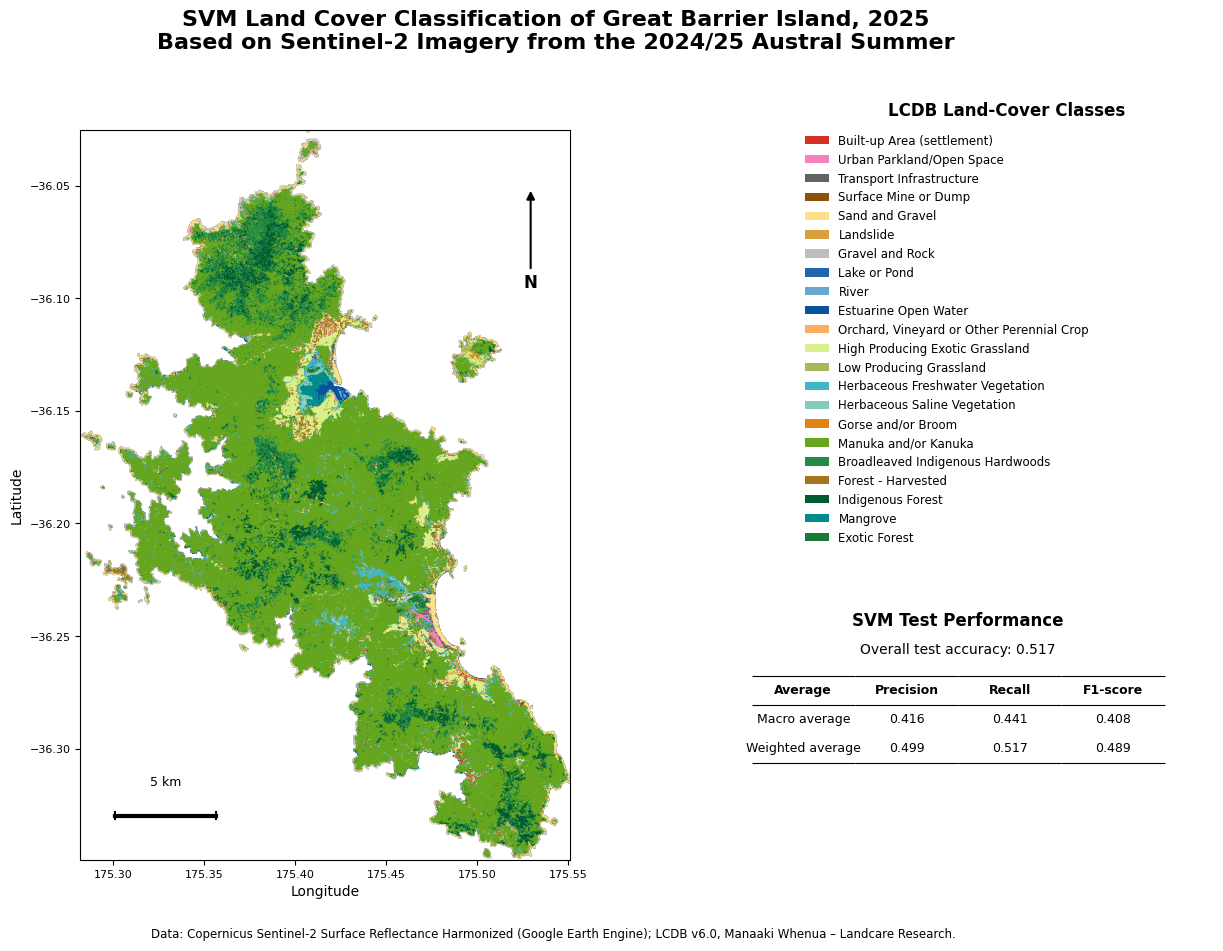

In [93]:
# Create the final publication-quality figure
figure_q6 = plt.figure(
    figsize=(14, 10)
)

grid_q6 = figure_q6.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[1.8, 1],
    height_ratios=[1.6, 1],
    left=0.07,
    right=0.97,
    top=0.84,
    bottom=0.11,
    wspace=0.18,
    hspace=0.20
)

# Main map
map_axis_q6 = figure_q6.add_subplot(grid_q6[:, 0])

# Legend panel
legend_axis_q6 = figure_q6.add_subplot(grid_q6[0, 1])

# Performance panel
performance_axis_q6 = figure_q6.add_subplot(grid_q6[1, 1])

performance_position_q6 = performance_axis_q6.get_position()

performance_axis_q6.set_position([
    performance_position_q6.x0 - 0.035,
    performance_position_q6.y0,
    performance_position_q6.width,
    performance_position_q6.height
])

# Plot the classified map
map_axis_q6.imshow(
    image_2025_q6,
    extent=extent_q6,
    origin='upper'
)

# Correct geographic aspect ratio
mean_latitude_q6 = (extent_q6[2] + extent_q6[3]) / 2

map_axis_q6.set_aspect(1 / np.cos(np.deg2rad(mean_latitude_q6)))

map_axis_q6.set_xlabel('Longitude', fontsize=10)

map_axis_q6.set_ylabel('Latitude', fontsize=10)

map_axis_q6.tick_params(labelsize=8)

add_map_elements_q6(map_axis_q6)

# Land-cover legend panel
legend_axis_q6.axis('off')

legend_axis_q6.set_title(
    'LCDB Land-Cover Classes',
    fontsize=12,
    fontweight='bold',
    pad=10
)

legend_axis_q6.legend(
    handles=legend_handles_q6,
    loc='upper left',
    frameon=False,
    fontsize=8.5,
    ncol=1,
    borderaxespad=0
)

# SVM test-performance summary
performance_axis_q6.axis('off')

performance_axis_q6.text(
    0.5,
    0.97,
    'SVM Test Performance',
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold',
    transform=performance_axis_q6.transAxes
)

performance_axis_q6.text(
    0.5,
    0.85,
    f'Overall test accuracy: {accuracy_q6:.3f}',
    ha='center',
    va='top',
    fontsize=10,
    transform=performance_axis_q6.transAxes
)

performance_table_data_q6 = [
    [
        'Macro average',
        f'{macro_precision_q6:.3f}',
        f'{macro_recall_q6:.3f}',
        f'{macro_f1_q6:.3f}'
    ],
    [
        'Weighted average',
        f'{weighted_precision_q6:.3f}',
        f'{weighted_recall_q6:.3f}',
        f'{weighted_f1_q6:.3f}'
    ]
]

performance_column_labels_q6 = [
    'Average',
    'Precision',
    'Recall',
    'F1-score'
]

performance_table_q6 = performance_axis_q6.table(
    cellText=performance_table_data_q6,
    colLabels=performance_column_labels_q6,
    cellLoc='center',
    colLoc='center',
    bbox=[0.0, 0.38, 1.0, 0.34]
)

performance_table_q6.auto_set_font_size(False)
performance_table_q6.set_fontsize(9)

# Format the performance table with minimal horizontal rules
cells_q6 = performance_table_q6.get_celld()

for (row_q6, col_q6), cell_q6 in cells_q6.items():

    cell_q6.set_facecolor('white')
    cell_q6.set_edgecolor('black')
    cell_q6.set_linewidth(0)
    cell_q6.visible_edges = ''

    if row_q6 == 0:
        cell_q6.set_text_props(
            fontweight='bold'
        )

# Top and header rules
for col_q6 in range(4):
    cells_q6[(0, col_q6)].visible_edges = 'TB'
    cells_q6[(0, col_q6)].set_linewidth(0.8)

# Bottom rule
for col_q6 in range(4):
    cells_q6[(2, col_q6)].visible_edges = 'B'
    cells_q6[(2, col_q6)].set_linewidth(0.8)

figure_q6.suptitle(
    'SVM Land Cover Classification of Great Barrier Island, 2025\n'
    'Based on Sentinel-2 Imagery from the 2024/25 Austral Summer',
    fontsize=16,
    fontweight='bold',
    y=0.96
)

# Data attribution
figure_q6.text(
    0.5,
    0.035,
    'Data: Copernicus Sentinel-2 Surface Reflectance Harmonized '
    '(Google Earth Engine); LCDB v6.0, Manaaki Whenua – Landcare Research. ',
    ha='center',
    va='center',
    fontsize=8.5
)

plt.show()